# 08 — Model stability analysis

**Goal:** Evaluate stability of feature importance across spatial folds.

We train LightGBM with **SpatialGroupKFold**, extract **feature_importances_** from each fold, then analyze mean importance, variability (std and coefficient of variation), and interpret which predictors are consistently important vs region-dependent.

# 1. Load dataset

Same preprocessing as in previous notebooks: load dataset, normalize column names, build feature matrix with `feature_columns`, and apply median imputation.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
import sys
sys.path.insert(0, str(ROOT))

from src.validation.spatial_cv import SpatialGroupKFold
from src.features.preprocess import feature_columns, impute_median

RAW = ROOT / "data" / "raw"
csv_path = RAW / "water_quality_dataset_v1.csv"
if not csv_path.exists():
    csv_path = RAW / "water_quality.csv"
if not csv_path.exists():
    raise FileNotFoundError("No water_quality_dataset_v1.csv or water_quality.csv in data/raw.")

df = pd.read_csv(csv_path)
if "Latitude" in df.columns and "lat" not in df.columns:
    df["lat"] = df["Latitude"]
if "Longitude" in df.columns and "lon" not in df.columns:
    df["lon"] = df["Longitude"]
for old, new in [("Total Alkalinity", "total_alkalinity"), ("Electrical Conductance", "electrical_conductance"), ("Dissolved Reactive Phosphorus", "dissolved_reactive_phosphorus")]:
    if old in df.columns and new not in df.columns:
        df[new] = df[old]

TARGET = "total_alkalinity"
if TARGET not in df.columns:
    TARGET = [c for c in ["total_alkalinity", "electrical_conductance", "dissolved_reactive_phosphorus"] if c in df.columns][0]

cols = feature_columns(df, exclude_targets=True)
X = df[cols].copy()
X, _ = impute_median(X)
y = df[TARGET].values
lat_arr = np.asarray(df["lat"] if "lat" in df.columns else df["Latitude"], dtype=float)
lon_arr = np.asarray(df["lon"] if "lon" in df.columns else df["Longitude"], dtype=float)

print(f"Loaded: {csv_path.name} | n = {len(df)} | target = {TARGET}")
print(f"Features: {len(cols)} columns")

Loaded: water_quality_dataset_v1.csv | n = 9319 | target = total_alkalinity
Features: 30 columns


# 2. SpatialGroupKFold training

Use **SpatialGroupKFold** with `n_splits=5`, `n_clusters=30`. Train a **LightGBM** model in each fold (fallback to RandomForest if LightGBM is not available).

In [2]:
N_SPLITS = 5
N_CLUSTERS = 30
RANDOM_STATE = 42

try:
    import lightgbm as lgb
    Model = lgb.LGBMRegressor
    model_kw = dict(n_estimators=150, max_depth=6, random_state=RANDOM_STATE, verbose=-1)
except ImportError:
    from sklearn.ensemble import RandomForestRegressor
    Model = RandomForestRegressor
    model_kw = dict(n_estimators=100, max_depth=10, random_state=RANDOM_STATE)

sgkf = SpatialGroupKFold(n_splits=N_SPLITS, n_clusters=N_CLUSTERS, random_state=RANDOM_STATE)
importance_per_fold = []

for fold, (tr, te) in enumerate(sgkf.split(np.zeros((len(y), 1)), lat=lat_arr, lon=lon_arr)):
    sc = StandardScaler().fit(X.iloc[tr])
    Xtr = pd.DataFrame(sc.transform(X.iloc[tr]), columns=X.columns)
    Xte = pd.DataFrame(sc.transform(X.iloc[te]), columns=X.columns)
    m = Model(**model_kw).fit(Xtr, y[tr])
    importance_per_fold.append(m.feature_importances_.copy())

imp_df = pd.DataFrame(importance_per_fold, columns=cols)
print(f"Feature importance stored for {len(importance_per_fold)} folds. Shape: {imp_df.shape}")

Feature importance stored for 5 folds. Shape: (5, 30)


# 3. Extract feature importance

Results are already stored in **imp_df**: each row is a fold, each column is a feature. We use this for the next steps.

In [3]:
print("Importance per fold (first 5 features):")
print(imp_df.iloc[:, :5].round(2))
print("...")

Importance per fold (first 5 features):
   pet  elevation  EVI  NDVI  Land Surface Temperature
0  281        297  125   107                       185
1  310        281  137   107                       216
2  256        346  144    88                       169
3  301        296  143    95                       191
4  333        268  138   117                       206
...


# 4. Analyze importance stability

Compute **mean** and **standard deviation** of importance across folds. Plot a **bar chart** of mean importance with **error bars** (std).

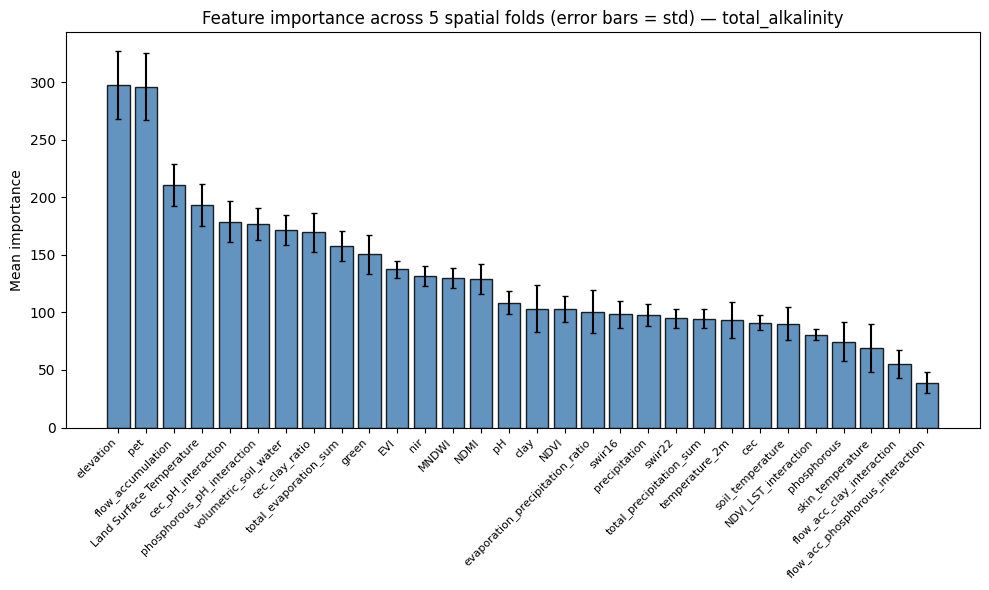

In [4]:
mean_imp = imp_df.mean(axis=0)
std_imp = imp_df.std(axis=0)
order = np.argsort(mean_imp.values)[::-1]
names_ordered = mean_imp.index[order].tolist()
mean_ordered = mean_imp.values[order]
std_ordered = std_imp.values[order]

fig, ax = plt.subplots(figsize=(10, 6))
x_pos = np.arange(len(names_ordered))
bars = ax.bar(x_pos, mean_ordered, yerr=std_ordered, capsize=2, color="steelblue", edgecolor="k", alpha=0.85)
ax.set_xticks(x_pos)
ax.set_xticklabels(names_ordered, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Mean importance")
ax.set_title(f"Feature importance across {N_SPLITS} spatial folds (error bars = std) — {TARGET}")
plt.tight_layout()
plt.show()

# 5. Stability metric

Compute **coefficient of variation** (CV = std / mean). High CV indicates **unstable** importance across folds (region-dependent). We mark unstable predictors where mean > 0 and CV is high.

In [5]:
with np.errstate(divide="ignore", invalid="ignore"):
    cv_imp = np.where(mean_imp > 1e-9, std_imp / mean_imp, np.nan)
cv_series = pd.Series(cv_imp, index=cols)
cv_series = cv_series.sort_values(ascending=False)

threshold_high_cv = 0.5
unstable = cv_series[cv_series > threshold_high_cv].dropna().index.tolist()
stable = cv_series[cv_series <= threshold_high_cv].dropna().index.tolist()

print(f"Coefficient of variation (std/mean) — threshold = {threshold_high_cv}")
print("-" * 50)
print(f"Unstable (CV > {threshold_high_cv}): {len(unstable)} features")
for f in unstable[:10]:
    print(f"  {f}: CV = {cv_series[f]:.3f}")
if len(unstable) > 10:
    print(f"  ... and {len(unstable) - 10} more")
print(f"\nStable (CV <= {threshold_high_cv}): {len(stable)} features")

Coefficient of variation (std/mean) — threshold = 0.5
--------------------------------------------------
Unstable (CV > 0.5): 0 features

Stable (CV <= 0.5): 30 features


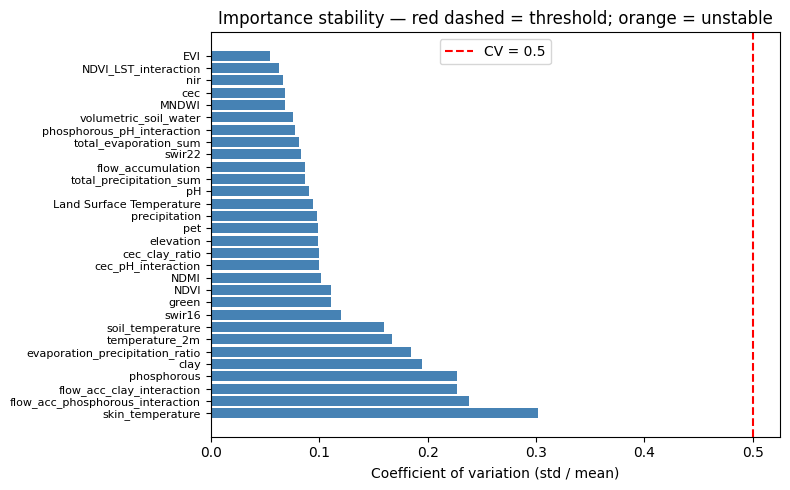

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
valid = cv_series.dropna()
colors = ["coral" if f in unstable else "steelblue" for f in valid.index]
ax.barh(range(len(valid)), valid.values, color=colors)
ax.axvline(threshold_high_cv, color="red", ls="--", label=f"CV = {threshold_high_cv}")
ax.set_yticks(range(len(valid)))
ax.set_yticklabels(valid.index, fontsize=8)
ax.set_xlabel("Coefficient of variation (std / mean)")
ax.set_title("Importance stability — red dashed = threshold; orange = unstable")
ax.legend()
plt.tight_layout()
plt.show()

# 6. Interpretation

## Which predictors are consistently important
- Features with **high mean importance** and **low CV** (small error bars, CV below the threshold) are **stable** across spatial folds. They matter in most regions and support a general interpretation (e.g. elevation or precipitation as broad drivers of water chemistry).

## Which predictors are region-dependent
- **High CV** (unstable) means importance varies a lot from fold to fold: the predictor may be strong in some regions and weak in others. This suggests **spatial non-stationarity** (e.g. a variable that matters in wet areas but not in dry ones) or **confounding** with region-specific factors. Such predictors are less reliable for a single global interpretation.

## Implications for environmental interpretation
- **Stable** predictors are better candidates for process-based narrative and for transfer to new areas, as long as the relationship is causal or well understood.
- **Unstable** predictors warrant caution: report them as region-dependent or consider **regional models** or **interaction terms** (e.g. with climate zone) if the goal is interpretability or generalization. The same analysis can be repeated for other targets (electrical_conductance, dissolved_reactive_phosphorus) to compare stability across water quality variables.